In [31]:
from scipy.io import arff
import pandas as pd

# 1. Charger le fichier
data, meta = arff.loadarff('../data/bone-marrow.arff')

# 2. Convertir en DataFrame et décoder le format (b'string' -> 'string')
df = pd.DataFrame(data)
df = df.apply(lambda x: x.str.decode('utf-8') if x.dtype == "object" else x)
df.index = df.index + 1
# 3. Vérifier que ça marche
df.head()

,Recipientgender,Stemcellsource,Donorage,Donorage35,IIIV,Gendermatch,DonorABO,RecipientABO,RecipientRh,ABOmatch,...,extcGvHD,CD34kgx10d6,CD3dCD34,CD3dkgx10d8,Rbodymass,ANCrecovery,PLTrecovery,time_to_aGvHD_III_IV,survival_time,survival_status
1,1,1,22.830137,0,1,0,1,1,1,0,...,1,7.20,1.338760,5.38,35.0,19.0,51.0,32.0,999.0,0.0
2,1,0,23.342466,0,1,0,-1,-1,1,0,...,1,4.50,11.078295,0.41,20.6,16.0,37.0,1000000.0,163.0,1.0
3,1,0,26.394521,0,1,0,-1,-1,1,0,...,1,7.94,19.013230,0.42,23.4,23.0,20.0,1000000.0,435.0,1.0
4,0,0,39.684932,1,1,0,1,2,1,1,...,?,4.25,29.481647,0.14,50.0,23.0,29.0,19.0,53.0,1.0
5,0,1,33.358904,0,0,0,1,2,0,1,...,1,51.85,3.972255,13.05,9.0,14.0,14.0,1000000.0,2043.0,0.0


In [32]:
# Affiche (lignes, colonnes)
print(f"Le dataset contient {df.shape[0]} patients et {df.shape[1]} variables.")

Le dataset contient 187 patients et 37 variables.


In [33]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 187 entries, 1 to 187
Data columns (total 37 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Recipientgender       187 non-null    object 
 1   Stemcellsource        187 non-null    object 
 2   Donorage              187 non-null    float64
 3   Donorage35            187 non-null    object 
 4   IIIV                  187 non-null    object 
 5   Gendermatch           187 non-null    object 
 6   DonorABO              187 non-null    object 
 7   RecipientABO          187 non-null    object 
 8   RecipientRh           187 non-null    object 
 9   ABOmatch              187 non-null    object 
 10  CMVstatus             187 non-null    object 
 11  DonorCMV              187 non-null    object 
 12  RecipientCMV          187 non-null    object 
 13  Disease               187 non-null    object 
 14  Riskgroup             187 non-null    object 
 15  Txpostrelapse         1

In [34]:
# Compte le nombre de valeurs vides par colonne
missing_data = df.isnull().sum()
print(missing_data[missing_data > 0]) # Affiche seulement celles qui ont des manques

CD3dCD34       5
CD3dkgx10d8    5
Rbodymass      2
dtype: int64


In [35]:
df.describe()

,Donorage,Recipientage,CD34kgx10d6,CD3dCD34,CD3dkgx10d8,Rbodymass,ANCrecovery,PLTrecovery,time_to_aGvHD_III_IV,survival_time,survival_status
count,187.000000,187.000000,187.000000,182.000000,182.000000,185.000000,187.000000,187.000000,187.000000,187.000000,187.000000
mean,33.472068,9.931551,11.891781,5.385096,4.745714,35.801081,26752.866310,90937.919786,775408.042781,938.743316,0.454545
std,8.271826,5.305639,9.914386,9.598716,3.859128,19.650922,161747.200525,288242.407688,418425.252689,849.589495,0.499266
min,18.646575,0.600000,0.790000,0.204132,0.040000,6.000000,9.000000,9.000000,10.000000,6.000000,0.000000
25%,27.039726,5.050000,5.350000,1.786683,1.687500,19.000000,13.000000,16.000000,1000000.000000,168.500000,0.000000
50%,33.550685,9.600000,9.720000,2.734462,4.325000,33.000000,15.000000,21.000000,1000000.000000,676.000000,0.000000
75%,40.117809,14.050000,15.415000,5.823565,6.785000,50.600000,17.000000,37.000000,1000000.000000,1604.000000,1.000000
max,55.553425,20.200000,57.780000,99.560970,20.020000,103.400000,1000000.000000,1000000.000000,1000000.000000,3364.000000,1.000000


In [36]:
# Remplace 'survival_status' par le nom exact de ta colonne de résultat (ex: 'survival')
# df['survival_status'].value_counts()

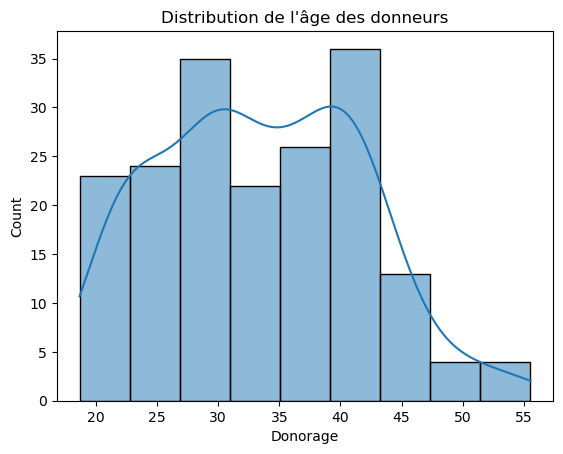

In [37]:
import seaborn as sns
import matplotlib.pyplot as plt

# Exemple : Distribution de l'âge des donneurs
sns.histplot(df['Donorage'], kde=True)
plt.title("Distribution de l'âge des donneurs")
plt.show()

In [38]:
# On ne garde que les colonnes numériques pour la corrélation
corr_matrix = df.select_dtypes(include=['float64', 'int64']).corr()

# Afficher la matrice
print(corr_matrix)

                      Donorage  Recipientage  CD34kgx10d6  CD3dCD34  \
Donorage              1.000000      0.094282     0.072530  0.144919   
Recipientage          0.094282      1.000000    -0.454347  0.053913   
CD34kgx10d6           0.072530     -0.454347     1.000000 -0.130573   
CD3dCD34              0.144919      0.053913    -0.130573  1.000000   
CD3dkgx10d8           0.023555     -0.430737     0.583284 -0.370918   
Rbodymass             0.106707      0.897538    -0.465137  0.061390   
ANCrecovery          -0.005872      0.114914    -0.086835  0.024662   
PLTrecovery          -0.056949      0.101815    -0.180256 -0.010890   
time_to_aGvHD_III_IV  0.016548      0.136641     0.010245  0.030236   
survival_time         0.005603     -0.137583     0.139313  0.044016   
survival_status       0.060384      0.203406    -0.146653  0.089868   

                      CD3dkgx10d8  Rbodymass  ANCrecovery  PLTrecovery  \
Donorage                 0.023555   0.106707    -0.005872    -0.056949   

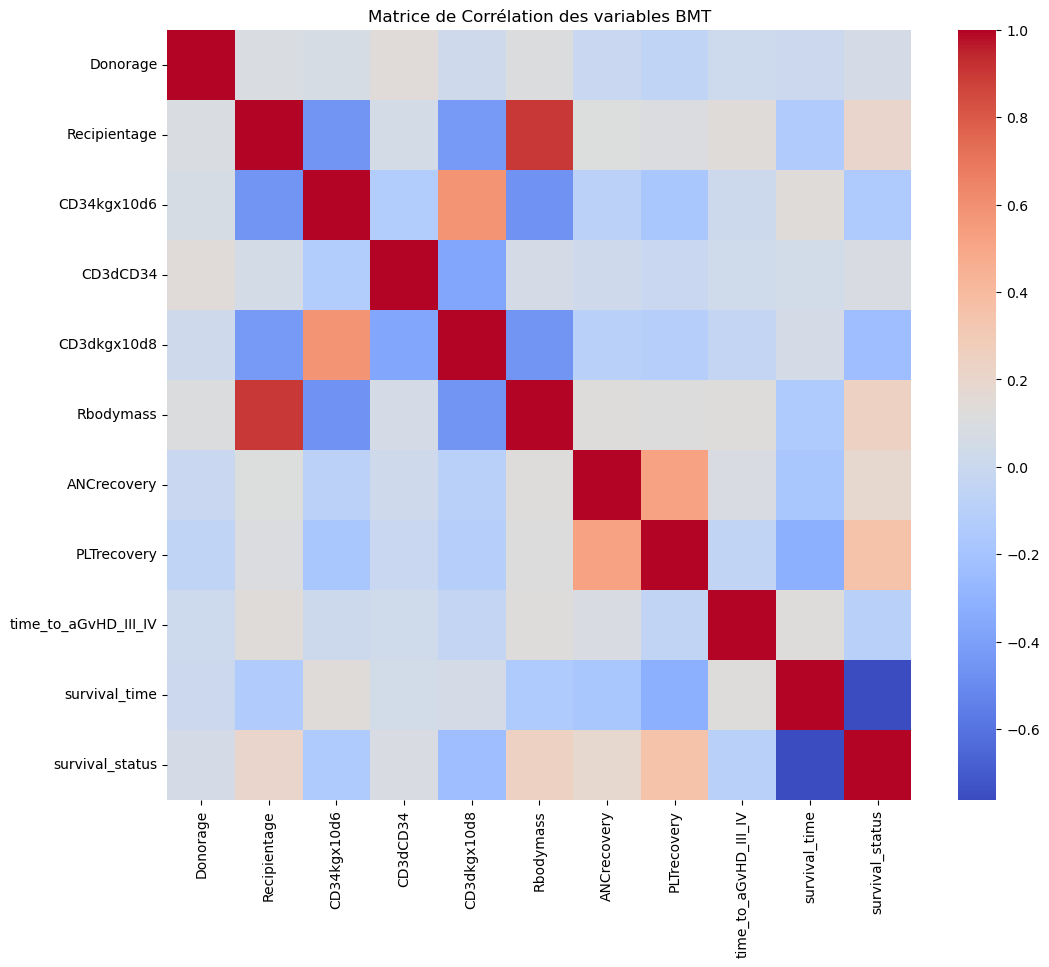

In [39]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', fmt=".2f")
plt.title("Matrice de Corrélation des variables BMT")
plt.show()

In [40]:
# On ne garde que les colonnes numériques pour la corrélation
corr_matrix = df.select_dtypes(include=['float64', 'int64']).corr()

# Afficher la matrice
print(corr_matrix)

                      Donorage  Recipientage  CD34kgx10d6  CD3dCD34  \
Donorage              1.000000      0.094282     0.072530  0.144919   
Recipientage          0.094282      1.000000    -0.454347  0.053913   
CD34kgx10d6           0.072530     -0.454347     1.000000 -0.130573   
CD3dCD34              0.144919      0.053913    -0.130573  1.000000   
CD3dkgx10d8           0.023555     -0.430737     0.583284 -0.370918   
Rbodymass             0.106707      0.897538    -0.465137  0.061390   
ANCrecovery          -0.005872      0.114914    -0.086835  0.024662   
PLTrecovery          -0.056949      0.101815    -0.180256 -0.010890   
time_to_aGvHD_III_IV  0.016548      0.136641     0.010245  0.030236   
survival_time         0.005603     -0.137583     0.139313  0.044016   
survival_status       0.060384      0.203406    -0.146653  0.089868   

                      CD3dkgx10d8  Rbodymass  ANCrecovery  PLTrecovery  \
Donorage                 0.023555   0.106707    -0.005872    -0.056949   

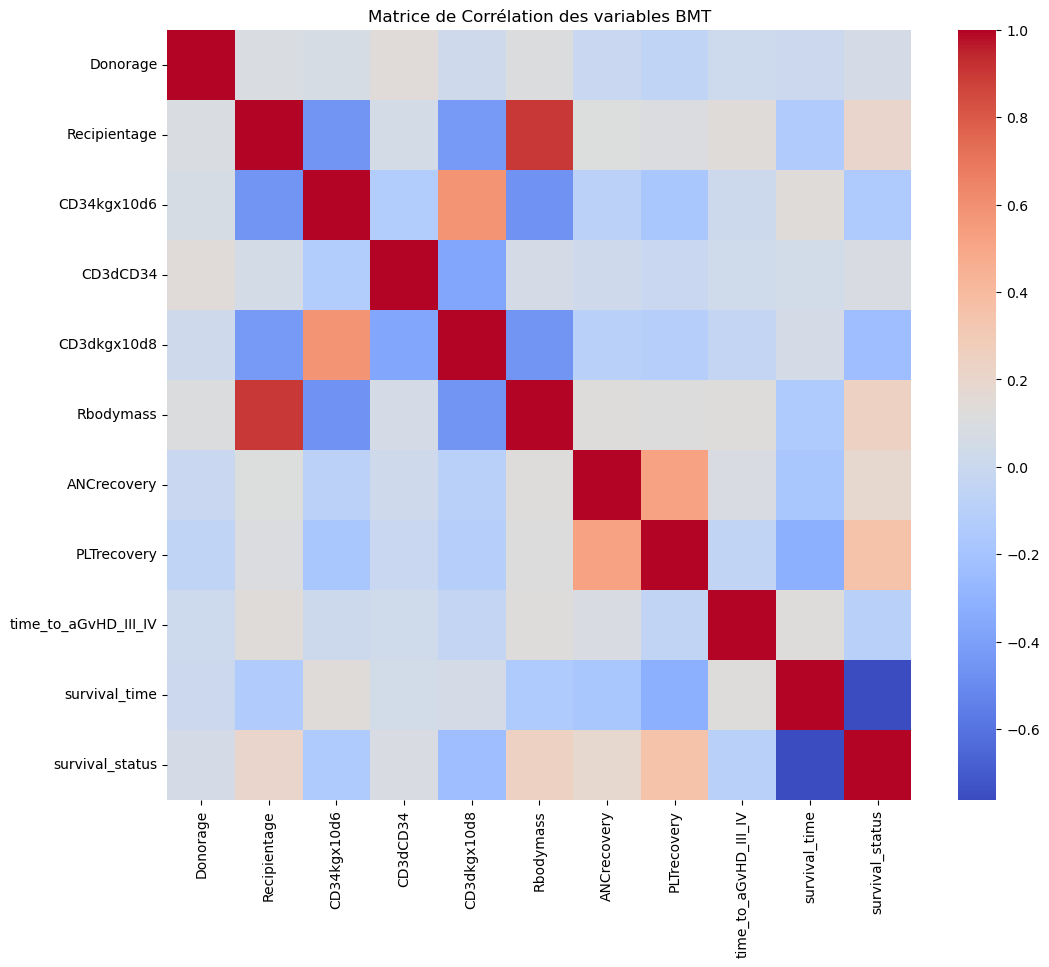

In [41]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', fmt=".2f")
plt.title("Matrice de Corrélation des variables BMT")
plt.show()

In [42]:
import numpy as np

# Calculer la matrice de corrélation absolue
corr_matrix = df.select_dtypes(include=[np.number]).corr().abs()

# Sélectionner le triangle supérieur de la matrice (pour éviter les doublons)
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# Trouver les colonnes avec une corrélation supérieure à 0.85
to_drop = [column for column in upper.columns if any(upper[column] > 0.85)]

print(f"Variables redondantes à supprimer : {to_drop}")

# Suppression effective
df_filtered = df.drop(columns=to_drop)

Variables redondantes à supprimer : ['Rbodymass']


In [43]:
# On regarde la corrélation de toutes les variables avec la cible 'survival_status'
target_corr = corr_matrix['survival_status'].sort_values(ascending=False)

print("Lien des variables avec la survie :")
print(target_corr)

# Stratégie : On pourrait écarter celles qui sont < 0.05 (très faibles)
weak_features = target_corr[target_corr < 0.05].index.tolist()
print(f"Variables avec un impact très faible : {weak_features}")

Lien des variables avec la survie :
survival_status         1.000000
survival_time           0.761462
PLTrecovery             0.346395
Rbodymass               0.238110
CD3dkgx10d8             0.232331
Recipientage            0.203406
ANCrecovery             0.181569
CD34kgx10d6             0.146653
time_to_aGvHD_III_IV    0.100601
CD3dCD34                0.089868
Donorage                0.060384
Name: survival_status, dtype: float64
Variables avec un impact très faible : []


In [44]:
# Focus sur la dose de cellules CD34
print(f"Corrélation CD34kgx10d6 / Survie : {corr_matrix.loc['CD34kgx10d6', 'survival_status']:.4f}")

Corrélation CD34kgx10d6 / Survie : 0.1467


Dataset : 187 patients, 37 variables
TEST DE NORMALITE
Donorage                       p=0.0019  Non normale
Recipientage                   p=0.0000  Non normale
CD34kgx10d6                    p=0.0000  Non normale
CD3dCD34                       p=0.0000  Non normale
CD3dkgx10d8                    p=0.0000  Non normale
Rbodymass                      p=0.0000  Non normale
ANCrecovery                    p=0.0000  Non normale
PLTrecovery                    p=0.0000  Non normale
time_to_aGvHD_III_IV           p=0.0000  Non normale
survival_time                  p=0.0000  Non normale
CORRELATION SPEARMAN
            Variable  Correlation  p-value
           Rbodymass       0.2149   0.0033
        Recipientage       0.2046   0.0050
         PLTrecovery       0.1976   0.0067
            CD3dCD34       0.1169   0.1161
            Donorage       0.0468   0.5252
         ANCrecovery       0.0446   0.5443
time_to_aGvHD_III_IV      -0.1016   0.1666
         CD34kgx10d6      -0.1965   0.0070
       

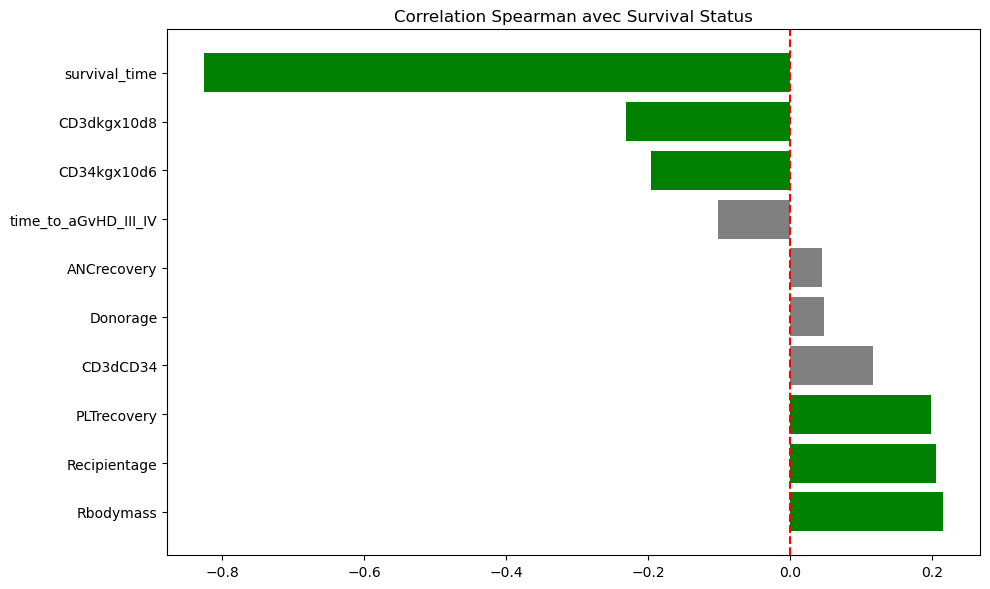

TEST MANN-WHITNEY
TEST CHI-2
Recipientgender                p=0.8595 ❌
Stemcellsource                 p=0.1207 ❌
Donorage35                     p=0.1583 ❌
IIIV                           p=0.4375 ❌
Gendermatch                    p=1.0000 ❌
DonorABO                       p=0.3912 ❌
RecipientABO                   p=0.7814 ❌
RecipientRh                    p=0.0677 ❌
ABOmatch                       p=0.2812 ❌
CMVstatus                      p=0.4800 ❌
DonorCMV                       p=0.7113 ❌
RecipientCMV                   p=0.1121 ❌
Disease                        p=0.0185 ✅
Riskgroup                      p=0.0618 ❌
Txpostrelapse                  p=0.1733 ❌
Diseasegroup                   p=0.4251 ❌
HLAmatch                       p=0.8680 ❌
HLAmismatch                    p=1.0000 ❌
Antigen                        p=0.7882 ❌
Alel                           p=0.7990 ❌
HLAgrI                         p=0.9415 ❌
Recipientage10                 p=0.0558 ❌
Recipientageint                p=0.1386 ❌
Relap

In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import shapiro, spearmanr, mannwhitneyu, chi2_contingency, kruskal
from scipy.io import arff

# 1. Charger le dataset
data, meta = arff.loadarff("../data/bone-marrow.arff")
df = pd.DataFrame(data)

# Décoder les colonnes bytes
for col in df.select_dtypes(include=['object']).columns:
    df[col] = df[col].str.decode('utf-8')

target = 'survival_status'
num_cols = [c for c in df.select_dtypes(include=['number']).columns if c != target]
cat_cols = [c for c in df.select_dtypes(include=['object']).columns if c != target]

print(f"Dataset : {df.shape[0]} patients, {df.shape[1]} variables")

# 2. Test normalité Shapiro-Wilk
print("TEST DE NORMALITE")
print("="*50)

for col in num_cols:
    data_col = df[col].dropna()
    if len(data_col) >= 3:
        stat, p = shapiro(data_col)
        result = "Normale" if p > 0.05 else "Non normale"
        print(f"{col:30s} p={p:.4f}  {result}")
# 3. Corrélation Spearman avec survie
print("CORRELATION SPEARMAN")
print("="*50)

results = []
for col in num_cols:
    tmp = df[[col, target]].dropna()
    if len(tmp) >= 3:
        corr, p = spearmanr(tmp[col], tmp[target])
        results.append((col, round(corr,4), round(p,4)))

df_corr = pd.DataFrame(results, columns=['Variable','Correlation','p-value'])
df_corr = df_corr.sort_values('Correlation', ascending=False)
print(df_corr.to_string(index=False))
# 4. Graphique corrélations
plt.figure(figsize=(10, 6))
colors = ['green' if p < 0.05 else 'gray' for p in df_corr['p-value']]
plt.barh(df_corr['Variable'], df_corr['Correlation'], color=colors)
plt.axvline(x=0, color='red', linestyle='--')
plt.title('Correlation Spearman avec Survival Status')
plt.tight_layout()
plt.savefig('../data/correlations.png', dpi=150)
plt.show()
        # 5. Mann-Whitney
print("TEST MANN-WHITNEY")
print("="*50)

for col in num_cols:
    g0 = df[df[target] == '0'][col].dropna()
    g1 = df[df[target] == '1'][col].dropna()
    if len(g0) >= 3 and len(g1) >= 3:
        stat, p = mannwhitneyu(g0, g1, alternative='two-sided')
        sig = "✅" if p < 0.05 else "❌"
        print(f"{col:30s} p={p:.4f} {sig}")

# 6. Chi-2
print("TEST CHI-2")
print("="*50)

for col in cat_cols:
    try:
        table = pd.crosstab(df[col], df[target])
        if table.shape[0] >= 2:
            chi2, p, dof, _ = chi2_contingency(table)
            sig = "✅" if p < 0.05 else "❌"
            print(f"{col:30s} p={p:.4f} {sig}")
    except:
        pass
# 7. Kruskal-Wallis
print("TEST KRUSKAL-WALLIS - CD34 selon maladie")
print("="*50)

try:
    disease_col = [c for c in df.columns if c.lower() == 'disease'][0]
    cd34_col = [c for c in df.columns if 'cd34' in c.lower() and 'kg' in c.lower()][0]
    
    groupes = [
        df[df[disease_col] == d][cd34_col].dropna()
        for d in df[disease_col].unique()
        if len(df[df[disease_col] == d][cd34_col].dropna()) >= 3
    ]
    
    if len(groupes) >= 2:
        stat, p = kruskal(*groupes)
        print(f"p-value : {p:.4f}")
        if p < 0.05:
            print("Difference significative ✅")
        else:
            print("Pas de difference ❌")
            
except Exception as e:
    print(f"Colonnes disponibles : {list(df.columns)}")
# IMPORTANT - Data Leakage !
print("ATTENTION : survival_time a exclure !")
print("Correlation = -0.82 avec survival_status")
print("Doit etre EXCLUE des features du modele ML !")
features_a_exclure = ['survival_time', 'survival_status']
print(f"Features a exclure : {features_a_exclure}")    